In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import json

import pickle

In [2]:
pred = pd.read_csv("/dccstor/ipc1/CAR/DREAM/Model/Test/After_synthetic/HCC70/LM_HCC70_EGF_predictions.csv", index_col=0)
true = pd.read_csv("/dccstor/ipc1/CAR/DREAM/Model/Test/After_synthetic/HCC70/valid_data.csv", index_col=0).reset_index(drop=True)

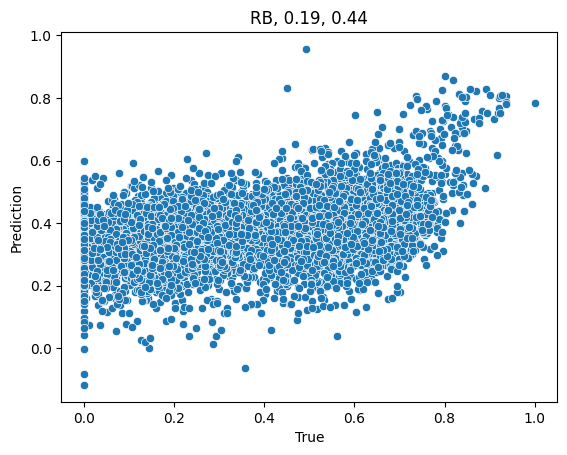

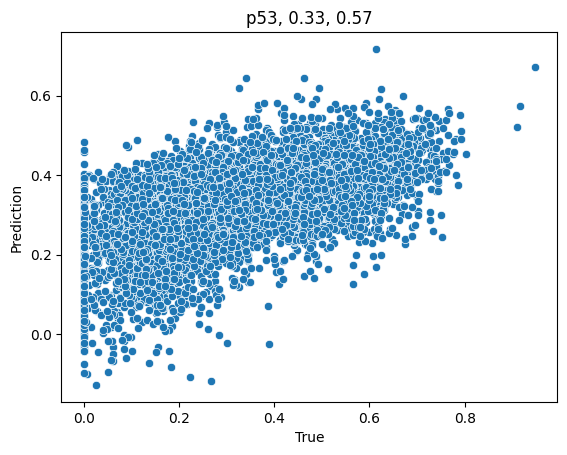

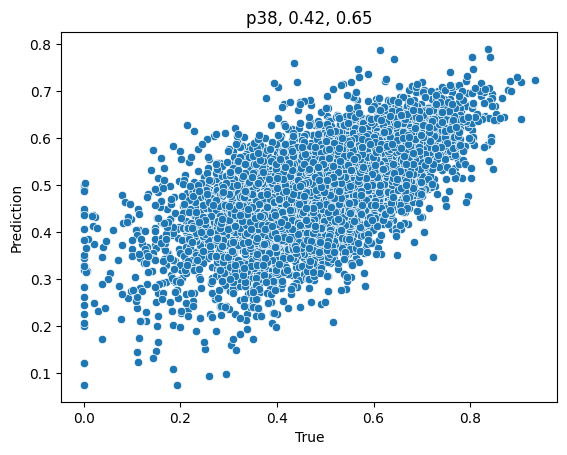

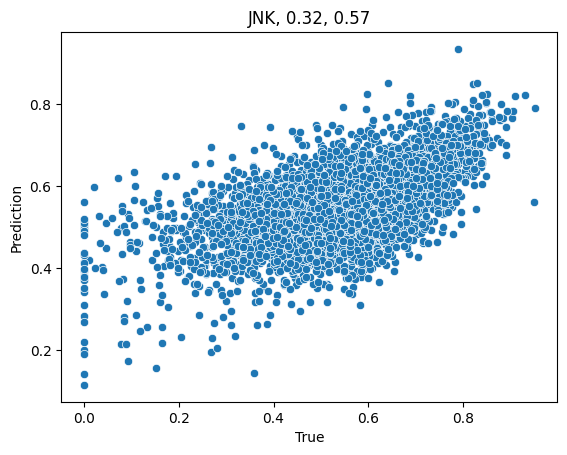

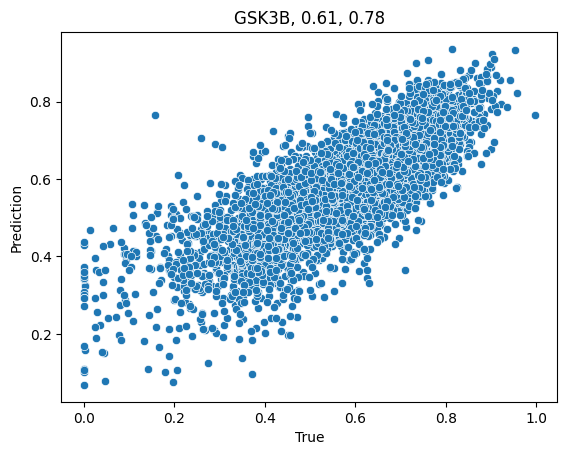

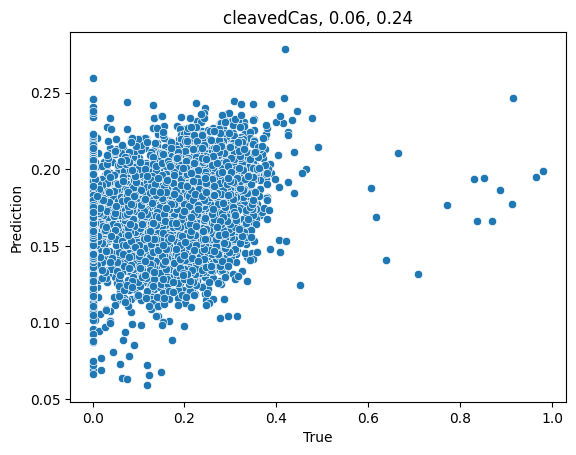

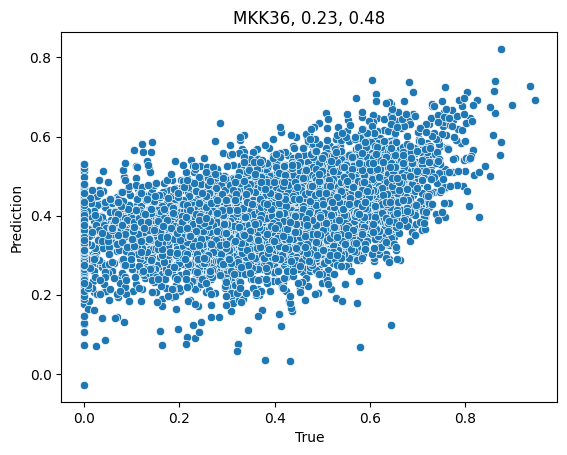

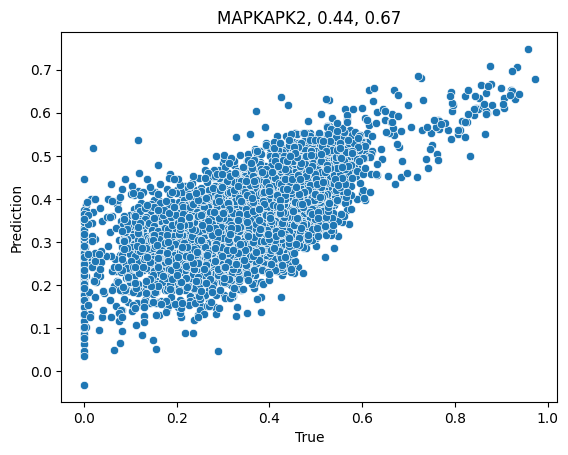

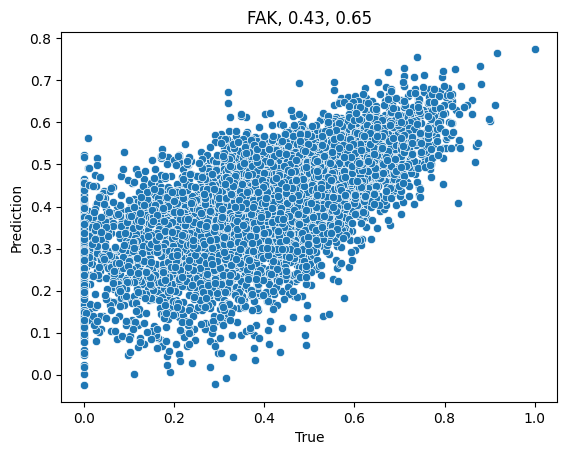

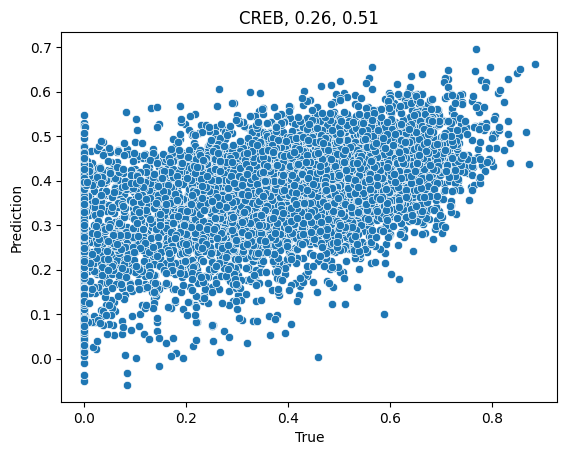

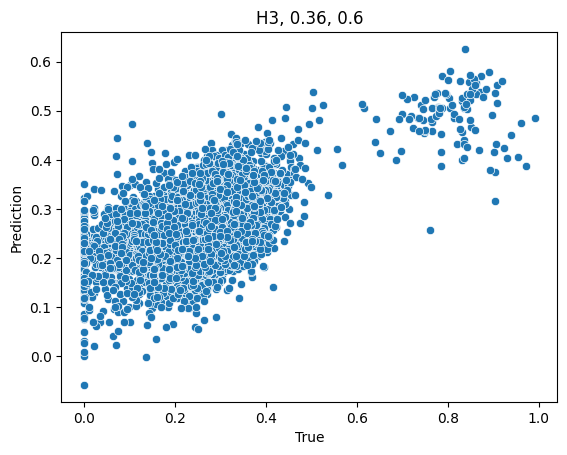

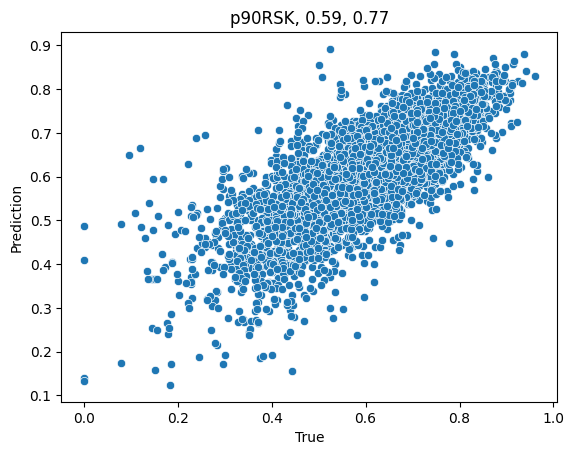

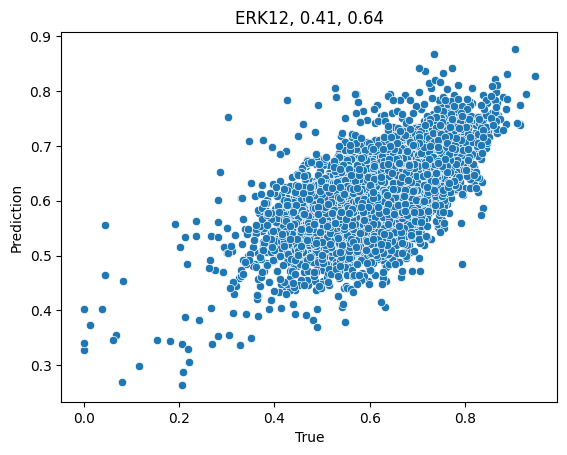

In [3]:
markers = set(pred.columns).intersection(set(true.columns))
# eval_markers = ["p.RB", "p.p53", "p.p38", "p.JNK", "p.GSK3b", "cleavedCas", "p.MKK3.MKK6", "p.MAPKAPK2", 
#                 "p.FAK", "p.CREB", "p.H3", "p.p90RSK", "p.ERK"]
eval_markers = [
    "RB",
    "p53",
    "p38",
    "JNK",
    "GSK3B",
    "cleavedCas",
    "MKK36",
    "MAPKAPK2",
    "FAK",
    "CREB",
    "H3",
    "p90RSK",
    "ERK12",
]
r2_scores = []
correlations = []
for marker in eval_markers:
    corr = true[marker].corr(pred[marker], method='pearson')
    correlations.append(corr)
    r2 = r2_score(true[marker], pred[marker])
    r2_scores.append(r2)
    sns.scatterplot(x=true[marker], y=pred[marker])
    plt.xlabel("True")
    plt.ylabel("Prediction")
    plt.title(f"{marker}, {round(r2, 2)}, {round(corr, 2)}")
    plt.show()

In [4]:
pd.Series(r2_scores).mean()

0.35717665342226024

In [5]:
pd.Series(correlations).mean()

0.5816292886134203

In [6]:
pred.max()

RB            0.956609
p53           0.717479
p38           0.789501
JNK           0.934227
GSK3B         0.935996
cleavedCas    0.278442
MKK36         0.821663
MAPKAPK2      0.747828
FAK           0.774975
CREB          0.695727
H3            0.626007
p90RSK        0.891891
ERK12         0.877001
dtype: float64

In [7]:
pred.min()

RB           -0.117161
p53          -0.128126
p38           0.074442
JNK           0.114890
GSK3B         0.067920
cleavedCas    0.059423
MKK36        -0.027902
MAPKAPK2     -0.031289
FAK          -0.024507
CREB         -0.059141
H3           -0.058575
p90RSK        0.124061
ERK12         0.263974
dtype: float64

In [8]:
with open("/dccstor/ipc1/CAR/DREAM/Model/Test/After_synthetic/HCC70/LM_HCC70_EGF.pkl", "rb") as f:
        model = pickle.load(f)

In [9]:
iMEK = pd.read_csv("/dccstor/ipc1/CAR/DREAM/Model/Test/After_synthetic/HCC70/valid_iMEK.csv")

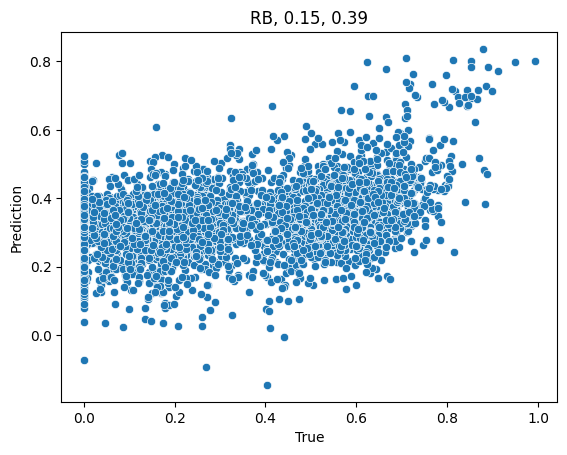

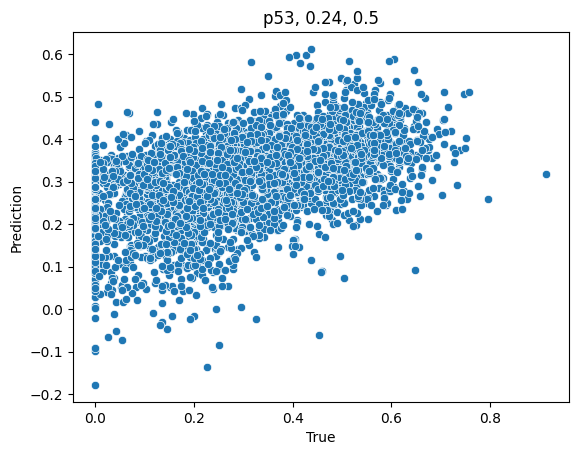

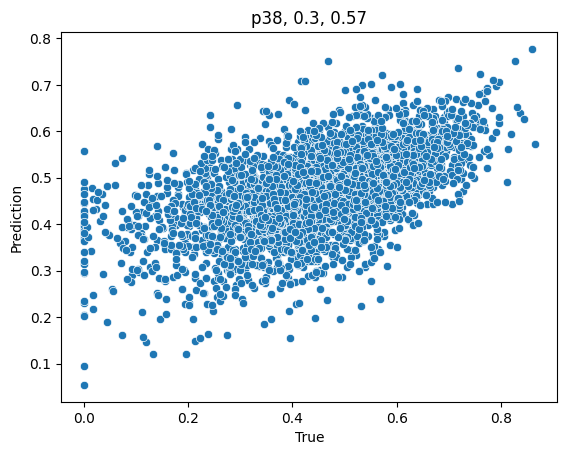

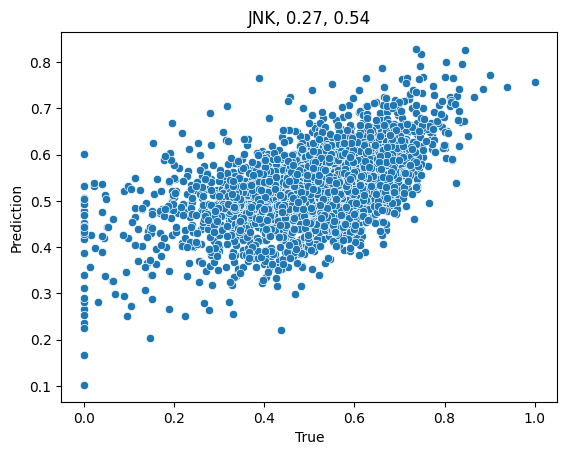

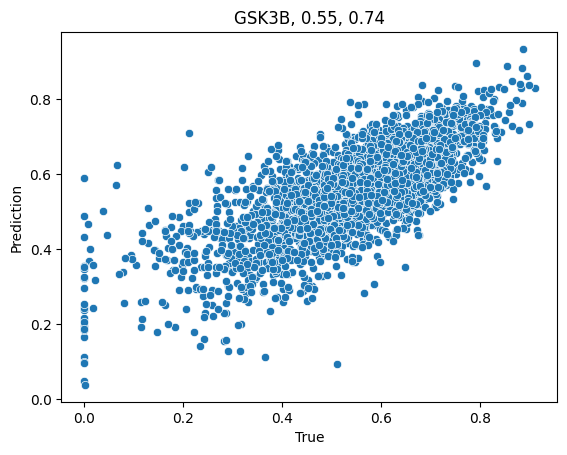

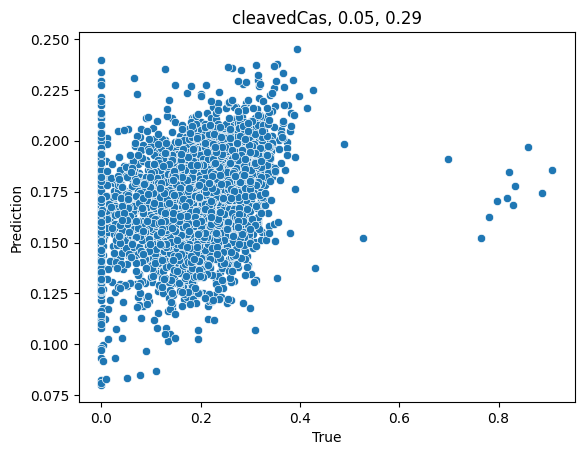

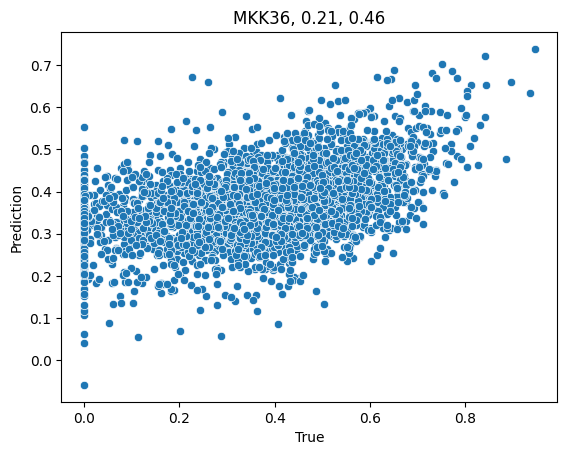

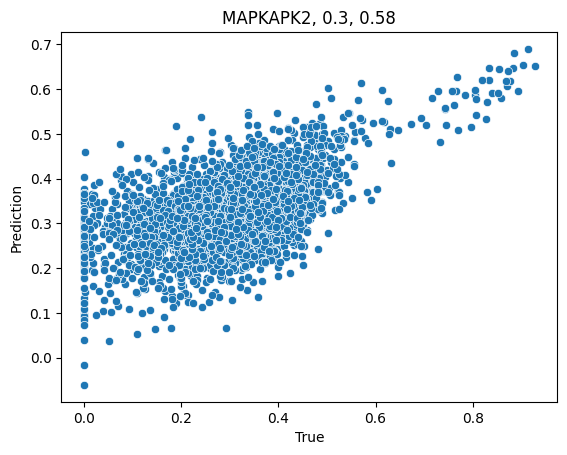

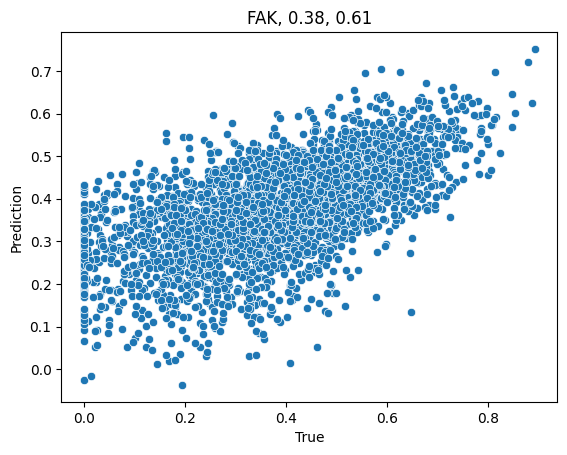

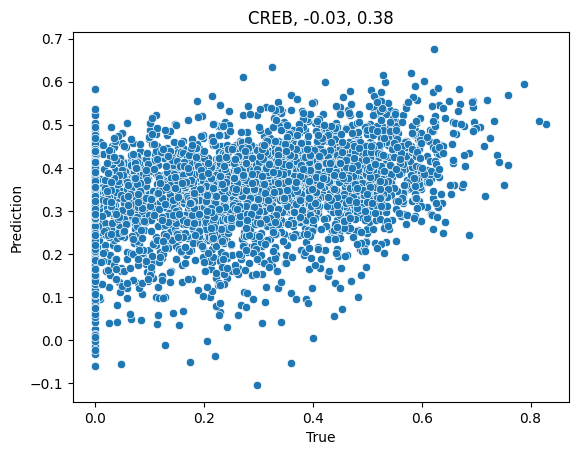

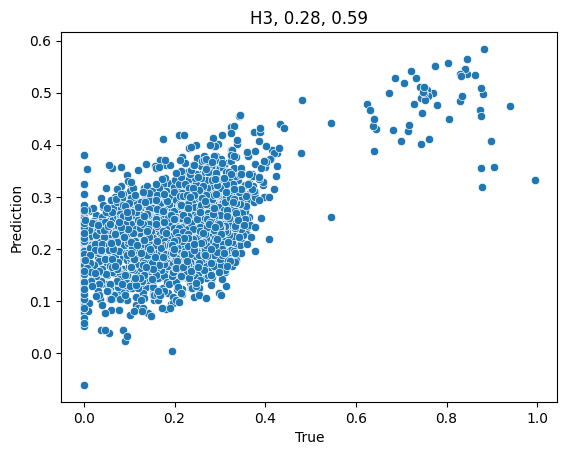

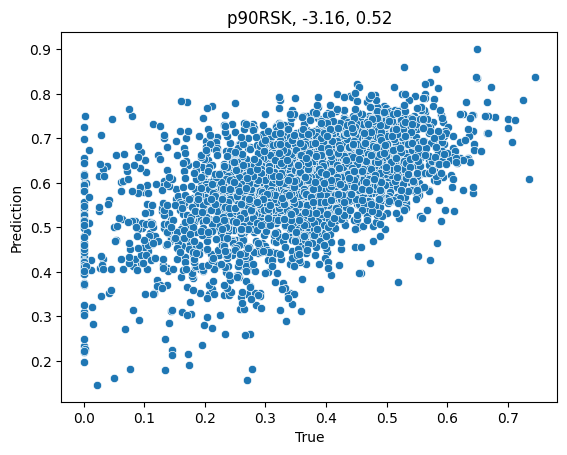

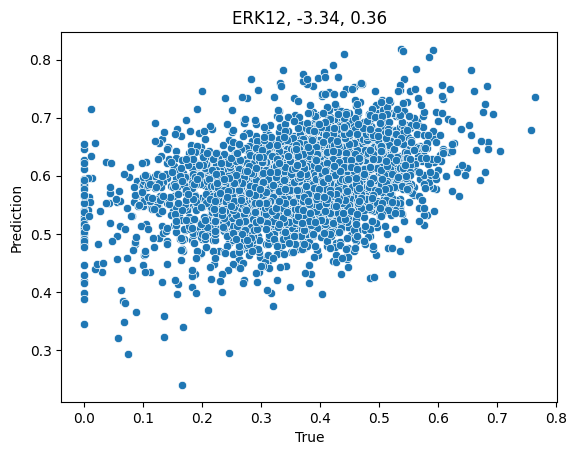

In [10]:
eval_markers = ["RB", "p53", "p38", "JNK", "GSK3B", "cleavedCas", "MKK36", "MAPKAPK2", 
                "FAK", "CREB", "H3", "p90RSK", "ERK12"]
ood_pred = pd.DataFrame(model.predict(iMEK[model.feature_names_in_]), columns=eval_markers)
r2_scores = []
correlations = []
for marker in eval_markers:
    corr = iMEK[marker].corr(ood_pred[marker], method='pearson')
    correlations.append(corr)
    r2 = r2_score(iMEK[marker], ood_pred[marker])
    r2_scores.append(r2)
    sns.scatterplot(x=iMEK[marker], y=ood_pred[marker])
    plt.xlabel("True")
    plt.ylabel("Prediction")
    plt.title(f"{marker}, {round(r2, 2)}, {round(corr, 2)}")
    plt.show()